# 09 - P(k) jitter in accDM runs

Notebook 08 showed ±0.5% node-to-node jitter in P_on/P_off at m = 10¹¹ GeV, k ≈ 0.05–0.5/Mpc. Emulators
need P(k) smooth to ~10⁻³.

**Test:** a *null pair*, two runs with identical physics whose k nodes are shifted (`k_step_sub` 0.05 vs
0.0505). Any difference between them is numerical or aliasing. Metric: residual of ln(P₁/P₂) about a
smooth degree-6 fit in ln k, on k ∈ [0.02, 2]/Mpc; target max < 10⁻³.

**Result.** The jitter is in every accDM run, sink on or off, and scales with f_acc; ΛCDM is clean. No
precision setting removes it, and smoothing cannot remove it without distorting the BAO. It lives only
in the daughter's own density: P_cb (CDM + baryons + parent) is clean to ~10⁻⁵. Notebook 10 shows the
cause: a physical oscillation of the daughter density in k, finer than CLASS's k spacing. Use P_cb for
galaxy clustering, as for massive neutrinos.

Model: m = 10¹¹ GeV (η = 1), κ = 12.1, a_t = 0.133, sink off, strategy 5 with 51 bins on the even grid
(as run on 2026-09-25), θ_s fixed. Cached in `09_cache.pkl`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter

from accdm_nb import RunCache, accdm_params, lcdm_params, ok, status, show, plot_style

plot_style()

KM = np.logspace(np.log10(0.02), np.log10(2.0), 400)        # 1/Mpc
SHIFT = {'k_step_sub': 0.0505}                                 # default 0.05
OUTPUT = {'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': 2500, 'P_k_max_1/Mpc': 10.0,
          'z_max_pk': 0.0, 'gauge': 'synchronous', '100*theta_s': 1.041783}


def pk(cosmo):
    return {'pk_m': np.array([cosmo.pk(k, 0.0) for k in KM]), 'pk_cb': np.array([cosmo.pk_cb(k, 0.0) for k in KM])}


def params(f_acc, **extra):
    p = accdm_params(f_acc, 1e11, ncdm_N_momentum_bins='15, 51', accdm_q_log_share=1, acc_de_sink='no',
                     **OUTPUT) if f_acc else lcdm_params(**OUTPUT)
    p.pop('H0')
    return {**p, **extra}


def residual(p1, p2):
    """ln(p1/p2) minus a smooth degree-6 fit in ln k."""
    x, y = np.log(KM), np.log(p1/p2)
    return y - np.polyval(np.polyfit(x, y, 6), x)


CASES = {'default': {}, 'k_step_sub 0.01': {'k_step_sub': 0.01}, 'k_step_sub 0.005': {'k_step_sub': 0.005},
         'tol_perturbations 1e-6': {'tol_perturbations_integration': 1e-6},
         '201 daughter bins': {'ncdm_N_momentum_bins': '15, 201'}, 'smooth births': {'accdm_smooth_births': 1}}

cache = RunCache('09_cache.pkl', extract=pk, workers=4)
# every run of the notebook, computed up front in parallel
cache.many([params(f, **x) for f in (0, 0.01, 0.1, 0.3) for x in ({}, SHIFT)]
           + [params(0.1, acc_de_sink='yes')]
           + [params(0.1, **{**x, 'k_step_sub': s*x.get('k_step_sub', 0.05)}) for x in CASES.values() for s in (1, 1.01)]
           + [params(f, k_per_decade_for_pk=kpd, **x) for f in (0, 0.3) for kpd in (10, 30) for x in ({}, SHIFT)])


def null_pair(f_acc, key='pk_m', **extra):
    a, b = cache.many([params(f_acc, **extra), params(f_acc, **extra, **SHIFT)], verbose=False)
    assert ok(a) and ok(b), (status(a), status(b))
    return residual(a[key], b[key])

28 new CLASS runs in 460 s


## 1. Which runs jitter

Null pairs for ΛCDM and three f_acc, and the original on/off comparison at f_acc = 0.1.

,rms,max
runs,,
"null pair, ΛCDM",8.1e-07,6.2e-06
"null pair, f_acc = 0.01",1.7e-04,8.2e-04
"null pair, f_acc = 0.1",1.7e-03,7.1e-03
"null pair, f_acc = 0.3",4.4e-03,1.9e-02
"sink on vs off, f_acc = 0.1",2.2e-03,7.8e-03


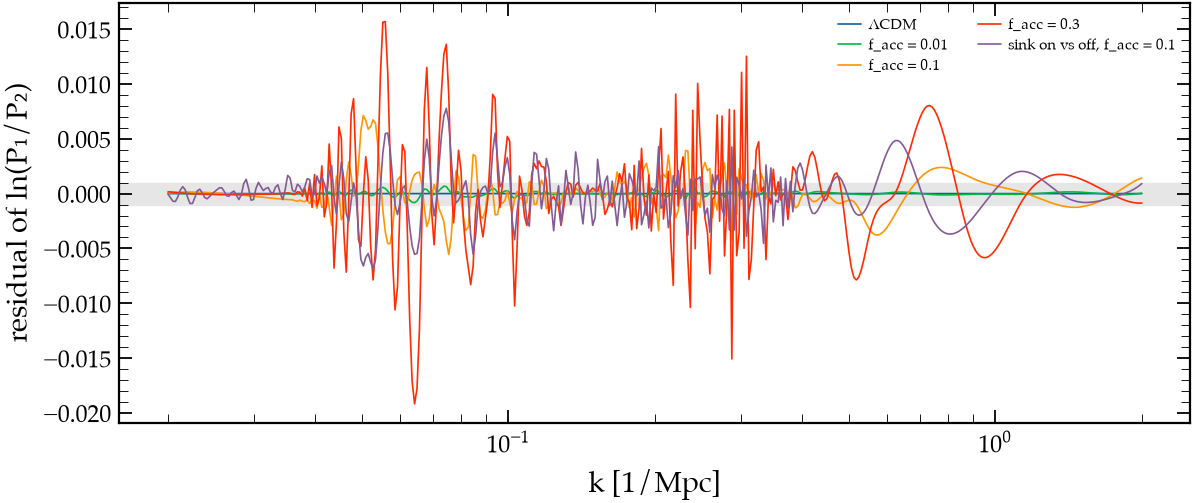

In [2]:
rows, curves = [], {}
for label, f in [('ΛCDM', 0), ('f_acc = 0.01', 0.01), ('f_acc = 0.1', 0.1), ('f_acc = 0.3', 0.3)]:
    curves[label] = r = null_pair(f)
    rows.append({'runs': 'null pair, ' + label, 'rms': np.sqrt(np.mean(r**2)), 'max': np.abs(r).max()})
off, on = cache.many([params(0.1), params(0.1, acc_de_sink='yes')], verbose=False)
curves['sink on vs off, f_acc = 0.1'] = r = residual(on['pk_m'], off['pk_m'])
rows.append({'runs': 'sink on vs off, f_acc = 0.1', 'rms': np.sqrt(np.mean(r**2)), 'max': np.abs(r).max()})
show(pd.DataFrame(rows).set_index('runs'), default='{:.1e}')

fig, ax = plt.subplots(figsize=(8, 3.4), constrained_layout=True)
for label, r in curves.items():
    ax.semilogx(KM, r, lw=0.8, label=label)
ax.axhspan(-1e-3, 1e-3, color='0.9', zorder=0)
ax.set_xlabel('k [1/Mpc]')
ax.set_ylabel('residual of ln(P₁/P₂)')
ax.legend(fontsize=7, ncol=2)
plt.show()

## 2. Precision does not remove it

The f_acc = 0.1 null pair under single changes: finer k sampling, tighter integration, more daughter
bins, and smooth births (each bin born gradually over its cell).

In [3]:
rows = []
for label, extra in CASES.items():
    a, b = cache.many([params(0.1, **{**extra, 'k_step_sub': s*extra.get('k_step_sub', 0.05)}) for s in (1, 1.01)],
                      verbose=False)
    r = residual(a['pk_m'], b['pk_m']) if ok(a) and ok(b) else np.full_like(KM, np.nan)
    rows.append({'setting': label, 'rms': np.sqrt(np.mean(r**2)), 'max': np.abs(r).max(), 'time [s]': a['sec']})
show(pd.DataFrame(rows).set_index('setting'), {'time [s]': '{:.0f}'}, default='{:.1e}')

,rms,max,time [s]
setting,,,
default,1.7e-03,7.1e-03,50
k_step_sub 0.01,6.7e-04,3.3e-03,103
k_step_sub 0.005,1.3e-03,5.5e-03,171
tol_perturbations 1e-6,1.7e-03,7.1e-03,60
201 daughter bins,1.4e-03,7.2e-03,159
smooth births,1.5e-03,5.2e-03,45


## 3. Smoothing

Could emulator training data simply be smoothed in ln k? Two requirements on k ∈ [0.03, 1.5]/Mpc at
f_acc = 0.3: the null pair agrees to 10⁻³ after smoothing, and smoothing a ΛCDM spectrum changes it by
less than 10⁻³ (BAO and curvature survive). Gaussian (σ = 0.05 in ln k) and Savitzky–Golay (window
0.15 in ln k, cubic), each at the default and at 3× denser P(k) sampling.

In [4]:
DLNK = np.log(KM[1]/KM[0])
INNER = (KM > 0.03) & (KM < 1.5)
SMOOTHERS = {'gauss 0.05': lambda y: gaussian_filter1d(y, 0.05/DLNK, mode='nearest'),
             'savgol 0.15/3': lambda y: savgol_filter(y, int(round(0.15/DLNK)) | 1, 3, mode='interp')}
rows = []
for kpd in (10, 30):
    extra = {'k_per_decade_for_pk': kpd}
    lcdm, a, b = cache.many([params(0, **extra), params(0.3, **extra), params(0.3, **extra, **SHIFT)], verbose=False)
    for name, sm in SMOOTHERS.items():
        rows.append({'k_per_decade_for_pk': kpd, 'smoother': name,
                     'raw null': np.abs(np.log(a['pk_m']/b['pk_m']))[INNER].max(),
                     'smoothed null': np.abs(sm(np.log(a['pk_m'])) - sm(np.log(b['pk_m'])))[INNER].max(),
                     'ΛCDM distortion': np.abs(sm(np.log(lcdm['pk_m'])) - np.log(lcdm['pk_m']))[INNER].max()})
table = pd.DataFrame(rows).set_index(['k_per_decade_for_pk', 'smoother'])
table['passes'] = (table['smoothed null'] < 1e-3) & (table['ΛCDM distortion'] < 1e-3)
show(table, default='{:.1e}')

raw null smoothed null ΛCDM distortion  \
k_per_decade_for_pk smoother                                               
10                  gauss 0.05     1.9e-02       6.8e-03         1.2e-02   
                    savgol 0.15/3  1.9e-02       1.3e-02         7.4e-04   
30                  gauss 0.05     2.1e-02       1.1e-02         1.2e-02   
                    savgol 0.15/3  2.1e-02       1.9e-02         7.4e-04   

                                  passes  
k_per_decade_for_pk smoother              
10                  gauss 0.05     False  
                    savgol 0.15/3  False  
30                  gauss 0.05     False  
                    savgol 0.15/3  False

## 4. P_cb

The f_acc = 0.3 null pair for total matter and for P_cb, and the size of the daughter's correction
ln(P_m/P_cb) that a total-matter probe (weak lensing) needs on top of P_cb.

pk_m   null max |Δ ln P| = 1.9e-02
pk_cb  null max |Δ ln P| = 1.4e-05
ln(P_m/P_cb) = -0.475 to -0.427


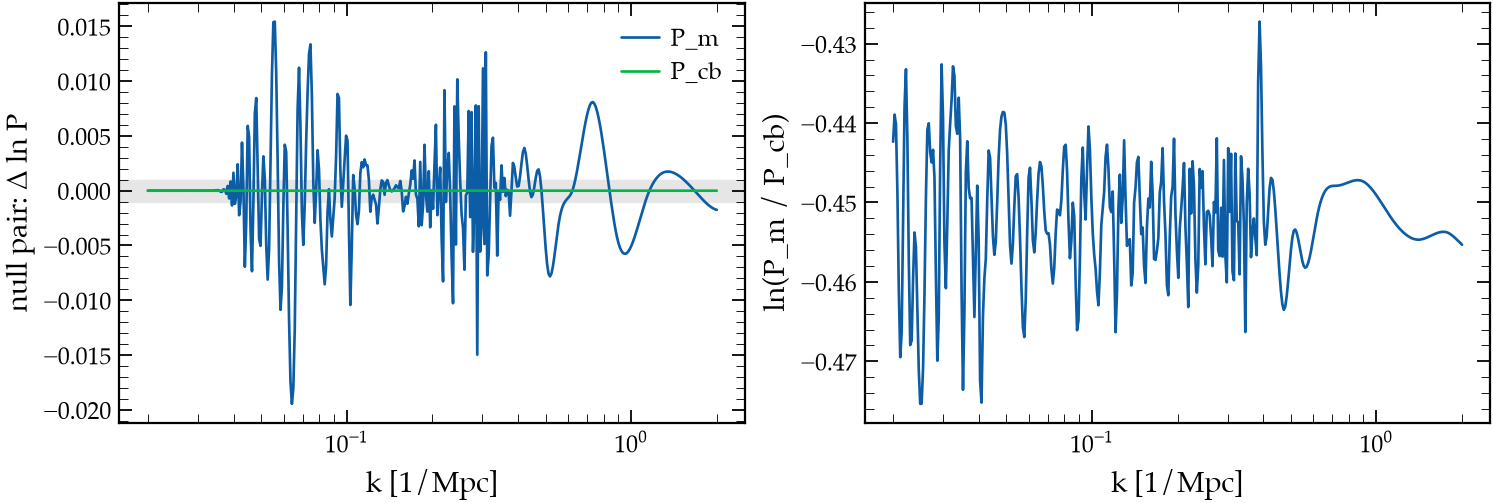

In [5]:
a, b = cache.many([params(0.3), params(0.3, **SHIFT)], verbose=False)
for key in ('pk_m', 'pk_cb'):
    print('{:<6} null max |Δ ln P| = {:.1e}'.format(key, np.abs(np.log(a[key]/b[key]))[INNER].max()))
ratio = np.log(a['pk_m']/a['pk_cb'])[INNER]
print('ln(P_m/P_cb) = {:+.3f} to {:+.3f}'.format(ratio.min(), ratio.max()))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), constrained_layout=True)
axes[0].semilogx(KM, np.log(a['pk_m']/b['pk_m']), label='P_m')
axes[0].semilogx(KM, np.log(a['pk_cb']/b['pk_cb']), label='P_cb')
axes[0].axhspan(-1e-3, 1e-3, color='0.9', zorder=0)
axes[0].set_ylabel('null pair: Δ ln P')
axes[0].legend()
axes[1].semilogx(KM, np.log(a['pk_m']/a['pk_cb']))
axes[1].set_ylabel('ln(P_m / P_cb)')
for ax in axes:
    ax.set_xlabel('k [1/Mpc]')
plt.show()